# Task 3 — Part A: Pool Ball Detection

**Goal:** Train an object detector that can locate every ball on a pool table, draw a bounding box around it, and label it with its category (`Black`, `Cue`, `Dot`, `Solid`, `Striped`).

**What we will build:**
1. Explore and understand the dataset (images + COCO annotations)
2. Convert the dataset to YOLO format (what the models expect)
3. Fine-tune **YOLOv8-s** — a fast, CNN-based single-stage detector
4. Fine-tune **RT-DETR-l** — a modern Transformer-based detector
5. Compare both models on standard detection metrics (mAP, precision, recall, speed)

> **Why these two?** They share the exact same Ultralytics training API, making a fair side-by-side comparison trivial to implement. The key difference is architectural: YOLO uses convolutional feature pyramids, while RT-DETR uses Transformer attention — exactly the CNN vs. Transformer narrative the "extra" comparison requires.

---
## 0. Install Dependencies

We only need one library: **Ultralytics**, which packages YOLOv8 and RT-DETR under a single, clean API. It also handles data augmentation, logging, and evaluation automatically.

In [1]:
# Install Ultralytics (includes YOLOv8 and RT-DETR)
# Run this only once — comment it out after the first run to save time
!pip install ultralytics --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import shutil
import random
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from ultralytics import YOLO, RTDETR

# Reproducibility
random.seed(42)
np.random.seed(42)

print("All imports successful!")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Lenovo\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
All imports successful!


---
## 1. Data Exploration

Before touching a model, always explore your data. We want to answer:
- How many images and annotations do we have?
- What categories exist, and how are they distributed?
- What do the images and ground-truth boxes look like?

Our dataset lives in `./train/` and uses **COCO JSON format**. In COCO:
- `images` → list of image metadata (id, file_name, width, height)
- `categories` → list of class names and their integer ids
- `annotations` → list of bounding boxes, each linked to an image and a category

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
TRAIN_DIR   = Path("./train")
COCO_JSON   = TRAIN_DIR / "_annotations.coco.json"  # adjust if your filename differs

# ── Load the COCO JSON ─────────────────────────────────────────────────────
with open(COCO_JSON) as f:
    coco = json.load(f)

print(f"Total images      : {len(coco['images'])}")
print(f"Total annotations : {len(coco['annotations'])}")
print(f"\nCategories:")
for cat in coco["categories"]:
    print(f"  id={cat['id']:>3}  name={cat['name']}")

Total images      : 247
Total annotations : 7244

Categories:
  id=  0  name=balls
  id=  1  name=Black
  id=  2  name=Cue
  id=  3  name=Dot
  id=  4  name=Solid
  id=  5  name=Striped


Annotation counts per class:
  Dot       : 4427
  Solid     : 1225
  Striped   : 1105
  Cue       : 245
  Black     : 242


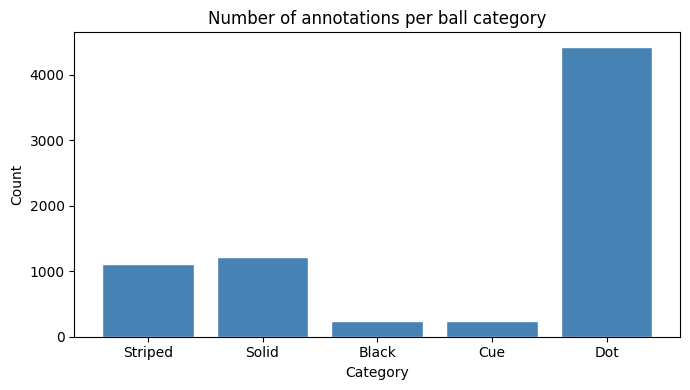

In [4]:
# ── Build helper look-up dictionaries ──────────────────────────────────────
# Map category id → name  (we will need this later)
id_to_name = {cat["id"]: cat["name"] for cat in coco["categories"]}

# Map image id → filename  (so we can load images by annotation)
id_to_file = {img["id"]: img["file_name"] for img in coco["images"]}

# ── Count annotations per category ─────────────────────────────────────────
# We skip the parent "balls" category (supercategory) if present —
# it is a grouping label, not a real detection class.
real_cat_ids = {cat["id"] for cat in coco["categories"] if cat["name"] != "balls"}

cat_counts = Counter(
    id_to_name[ann["category_id"]]
    for ann in coco["annotations"]
    if ann["category_id"] in real_cat_ids
)

print("Annotation counts per class:")
for name, count in sorted(cat_counts.items(), key=lambda x: -x[1]):
    print(f"  {name:<10}: {count}")

# ── Bar chart ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(cat_counts.keys(), cat_counts.values(), color="steelblue", edgecolor="white")
ax.set_title("Number of annotations per ball category")
ax.set_ylabel("Count")
ax.set_xlabel("Category")
plt.tight_layout()
plt.show()

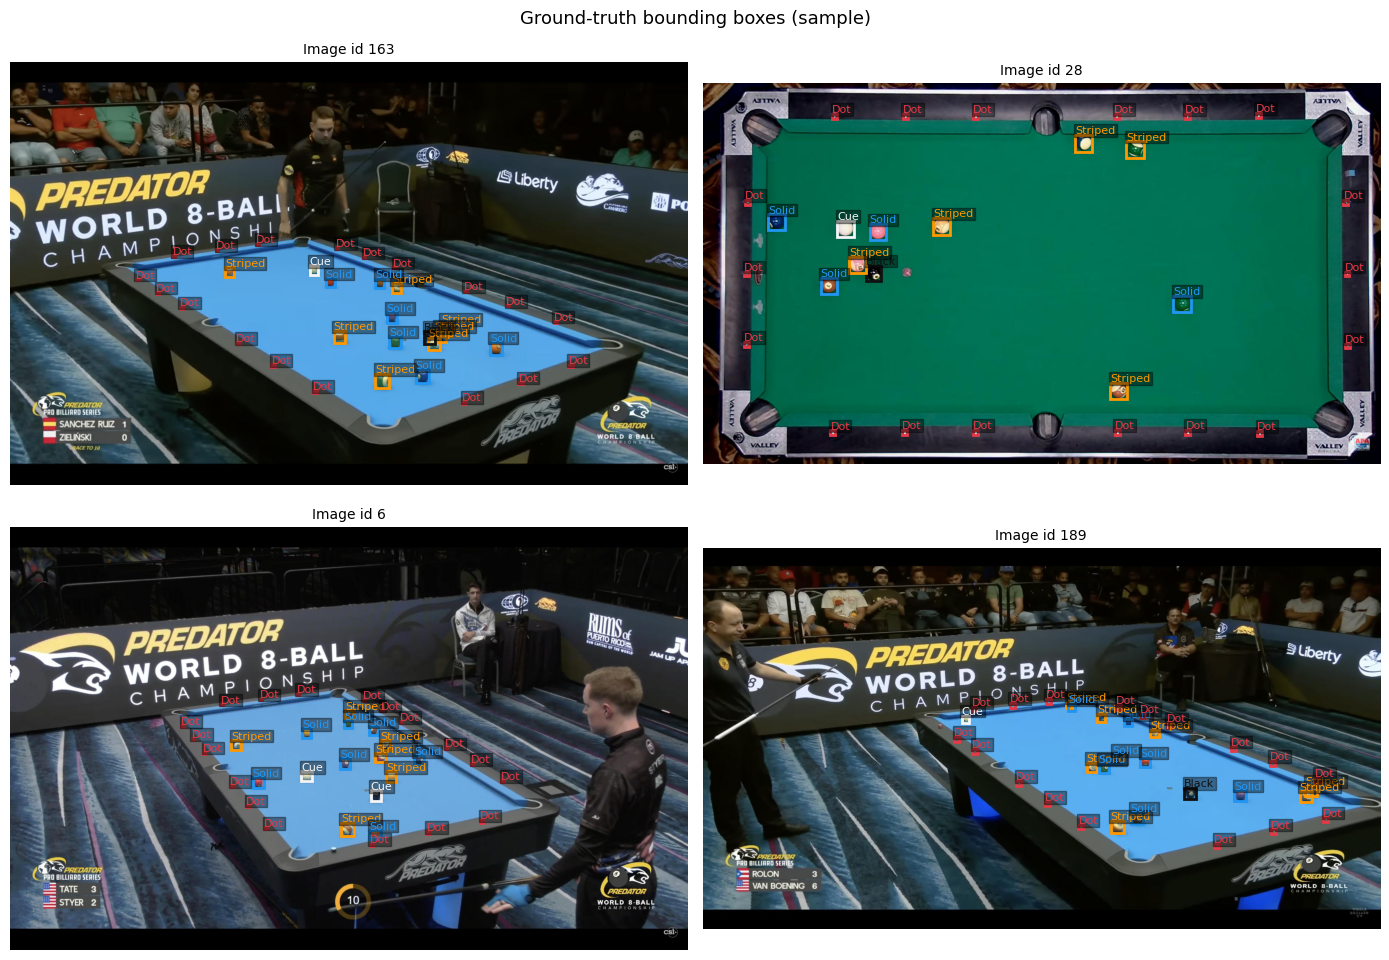

In [5]:
# ── Visualise ground-truth boxes on a few sample images ────────────────────
# This is the single most important sanity check: confirm your annotations
# actually sit on the correct objects before spending time training.

# Build a dict: image_id → list of annotations
ann_by_img = {}
for ann in coco["annotations"]:
    if ann["category_id"] not in real_cat_ids:
        continue
    ann_by_img.setdefault(ann["image_id"], []).append(ann)

# Colour palette for each class
PALETTE = {
    "Black"  : "#111111",
    "Cue"    : "#f5f5f5",
    "Dot"    : "#e63946",
    "Solid"  : "#2196f3",
    "Striped": "#ff9800",
}

sample_ids = random.sample(list(ann_by_img.keys()), k=4)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, img_id in zip(axes.flat, sample_ids):
    img_path = TRAIN_DIR / id_to_file[img_id]
    img_bgr  = cv2.imread(str(img_path))
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)

    for ann in ann_by_img[img_id]:
        x, y, w, h = ann["bbox"]          # COCO bbox: [x_min, y_min, width, height]
        cat_name   = id_to_name[ann["category_id"]]
        color      = PALETTE.get(cat_name, "lime")
        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x, y - 4, cat_name, color=color, fontsize=8,
                bbox=dict(facecolor="black", alpha=0.4, pad=1))

    ax.set_title(f"Image id {img_id}", fontsize=10)
    ax.axis("off")

plt.suptitle("Ground-truth bounding boxes (sample)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 2. Data Preparation: COCO → YOLO Format

Ultralytics models expect data in **YOLO format**, which is different from COCO:

| Format | Annotation file | Box representation |
|--------|----------------|--------------------|
| COCO   | One big JSON   | `[x_min, y_min, width, height]` in pixels |
| YOLO   | One `.txt` per image | `[class_id, x_center, y_center, width, height]` **normalised 0–1** |

We also need to **create train/val/test splits** ourselves (our dataset has no pre-made splits).

**Split strategy:** 70% train / 15% val / 15% test, stratified at the image level.

In [6]:
# ── 2.1  Map category name → 0-indexed YOLO class id ───────────────────────
# YOLO class ids must start at 0 and be contiguous.
# We sort alphabetically for reproducibility.
CLASS_NAMES  = sorted([cat["name"] for cat in coco["categories"]
                       if cat["name"] != "balls"])
name_to_yolo = {name: idx for idx, name in enumerate(CLASS_NAMES)}
print("YOLO class mapping:", name_to_yolo)

YOLO class mapping: {'Black': 0, 'Cue': 1, 'Dot': 2, 'Solid': 3, 'Striped': 4}


In [7]:
# ── 2.2  Create the directory structure expected by Ultralytics ─────────────
#
#   dataset/
#   ├── images/
#   │   ├── train/   ← image files (.jpg)
#   │   ├── val/
#   │   └── test/
#   └── labels/
#       ├── train/   ← one .txt per image
#       ├── val/
#       └── test/

DATASET_DIR = Path("./dataset")

for split in ["train", "val", "test"]:
    (DATASET_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

print("Directory structure created.")

Directory structure created.


In [8]:
# ── 2.3  Split image ids into train / val / test ────────────────────────────
# Only keep images that have at least one real annotation.
all_img_ids = sorted(ann_by_img.keys())
random.shuffle(all_img_ids)

n       = len(all_img_ids)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
# Test gets the remainder

splits = {
    "train": all_img_ids[:n_train],
    "val"  : all_img_ids[n_train : n_train + n_val],
    "test" : all_img_ids[n_train + n_val :],
}

for split, ids in splits.items():
    print(f"{split:>5}: {len(ids):>4} images")

train:  172 images
  val:   37 images
 test:   38 images


In [9]:
# ── 2.4  Convert annotations and copy images ────────────────────────────────
# For each image:
#   1. Copy the .jpg to dataset/images/<split>/
#   2. Write a .txt file to dataset/labels/<split>/
#      Each line: <class_id> <x_center> <y_center> <width> <height>  (all 0-1)

# Build a quick lookup: image_id → (width, height)
img_dims = {img["id"]: (img["width"], img["height"]) for img in coco["images"]}

def coco_bbox_to_yolo(bbox, img_w, img_h):
    """Convert COCO [x_min, y_min, w, h] to YOLO [xc, yc, w, h] normalised."""
    x_min, y_min, w, h = bbox
    x_center = (x_min + w / 2) / img_w
    y_center = (y_min + h / 2) / img_h
    return x_center, y_center, w / img_w, h / img_h

for split, img_ids in splits.items():
    for img_id in img_ids:
        img_info  = next(img for img in coco["images"] if img["id"] == img_id)
        fname     = img_info["file_name"]
        img_w, img_h = img_dims[img_id]

        # 1. Copy image
        src = TRAIN_DIR / fname
        dst = DATASET_DIR / "images" / split / fname
        shutil.copy(src, dst)

        # 2. Write label file
        label_path = DATASET_DIR / "labels" / split / (Path(fname).stem + ".txt")
        lines = []
        for ann in ann_by_img.get(img_id, []):
            cat_name = id_to_name[ann["category_id"]]
            class_id = name_to_yolo[cat_name]
            xc, yc, w, h = coco_bbox_to_yolo(ann["bbox"], img_w, img_h)
            # Clamp values to [0, 1] to handle any annotation boundary errors
            xc = max(0.0, min(1.0, xc))
            yc = max(0.0, min(1.0, yc))
            w  = max(0.0, min(1.0, w))
            h  = max(0.0, min(1.0, h))
            lines.append(f"{class_id} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}")

        label_path.write_text("\n".join(lines))

print("Dataset converted and organised successfully!")

Dataset converted and organised successfully!


In [10]:
# ── 2.5  Write the YAML config file ────────────────────────────────────────
# Ultralytics reads a .yaml file to know where the data lives and
# how many classes exist. This is the only configuration file we need.

yaml_content = f"""# Pool Ball Detection Dataset
path: {DATASET_DIR.resolve()}  # absolute path to dataset root

train: images/train
val:   images/val
test:  images/test

nc: {len(CLASS_NAMES)}  # number of classes
names: {CLASS_NAMES}
"""

yaml_path = Path("pool_balls.yaml")
yaml_path.write_text(yaml_content)
print(yaml_path.read_text())

# Pool Ball Detection Dataset
path: C:\Users\Lenovo\Desktop\Master\VC\CV-TASK2-3\dataset  # absolute path to dataset root

train: images/train
val:   images/val
test:  images/test

nc: 5  # number of classes
names: ['Black', 'Cue', 'Dot', 'Solid', 'Striped']



---
## 3. Model Training

### What is fine-tuning?

Instead of training from random weights (which would need thousands of images), we start from a model that was **pre-trained on COCO** (a large general-purpose detection dataset). We then continue training it on our small pool-ball dataset. The model already knows how to detect edges, shapes, and objects in general — we just teach it to specialise.

### YOLOv8-s — CNN-based detector

YOLOv8 divides the image into a grid. Each grid cell predicts bounding boxes and class probabilities simultaneously in a single forward pass — hence *single-stage*. It uses a **convolutional feature pyramid** to detect objects at multiple scales (useful since pool balls appear at very different sizes depending on camera distance).

### RT-DETR-l — Transformer-based detector

RT-DETR uses a **Transformer encoder** to model global relationships between all image patches. This means a ball in the corner of the image can "attend" to context across the whole scene. Unlike YOLO, it does **not use Non-Maximum Suppression (NMS)** — it directly outputs a fixed set of predictions, which makes its output cleaner but convergence slower.

> **Note:** Both models share the exact same `.train()` API — the only difference is which class you instantiate.

In [11]:
# ── Training hyperparameters ────────────────────────────────────────────────
# These are conservative, Colab-friendly values.
# Increase epochs (up to 100) if you have more compute budget.

EPOCHS    = 50    # number of full passes over the training set
IMG_SIZE  = 640   # resize all images to 640×640 (standard for YOLO)
BATCH     = 16    # images per gradient update (reduce to 8 if you get OOM errors)
DATA_YAML = str(yaml_path.resolve())

print(f"Training config: epochs={EPOCHS}, imgsz={IMG_SIZE}, batch={BATCH}")

Training config: epochs=50, imgsz=640, batch=16


In [12]:
# ── 3.1  Train YOLOv8-s ─────────────────────────────────────────────────────
# "yolov8s.pt" downloads the small variant pre-trained on COCO.
# The "s" = small — fast enough for Colab free tier.

print("=" * 60)
print("Training YOLOv8-s...")
print("=" * 60)

yolo_model = YOLO("yolov8s.pt")

yolo_results = yolo_model.train(
    data    = DATA_YAML,
    epochs  = EPOCHS,
    imgsz   = IMG_SIZE,
    batch   = BATCH,
    name    = "yolov8s_pool",   # results saved to runs/detect/yolov8s_pool/
    exist_ok= True,
    verbose = False,            # set True for per-epoch logs
)

print("\nYOLOv8-s training complete!")

Training YOLOv8-s...
New https://pypi.org/project/ultralytics/8.4.68 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.41  Python-3.13.5 torch-2.10.0+cpu CPU (AMD Ryzen 5 2500U with Radeon Vega Mobile Gfx)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Lenovo\Desktop\Master\VC\CV-TASK2-3\pool_balls.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, 

KeyboardInterrupt: 

In [ ]:
# ── 3.2  Train RT-DETR-l ────────────────────────────────────────────────────
# The Transformer model. Same API, different class.
# Use batch=8 instead of 16 — RT-DETR is heavier on memory.

print("=" * 60)
print("Training RT-DETR-l...")
print("=" * 60)

rtdetr_model = RTDETR("rtdetr-l.pt")

rtdetr_results = rtdetr_model.train(
    data    = DATA_YAML,
    epochs  = EPOCHS,
    imgsz   = IMG_SIZE,
    batch   = 8,              # smaller batch for RT-DETR (heavier model)
    name    = "rtdetr_pool",  # results saved to runs/detect/rtdetr_pool/
    exist_ok= True,
    verbose = False,
)

print("\nRT-DETR-l training complete!")

---
## 4. Evaluation

We evaluate both models on the **held-out test set** — images the model has never seen.

### Key metrics explained

| Metric | Meaning | Range |
|--------|---------|-------|
| **Precision** | Of all boxes the model predicted, what fraction were correct? | 0–1, higher is better |
| **Recall** | Of all ground-truth boxes, what fraction did the model find? | 0–1, higher is better |
| **mAP@50** | Mean Average Precision at IoU ≥ 0.50 — the standard detection metric | 0–1, higher is better |
| **mAP@50:95** | Stricter: average mAP across IoU thresholds 0.50 to 0.95 | 0–1, higher is better |

**IoU (Intersection over Union)** measures how much a predicted box overlaps the ground-truth box:
- IoU = 1.0 → perfect overlap
- IoU < 0.5 → prediction is too far off to count as correct

**mAP** averages the Average Precision over all classes. It summarises the precision-recall trade-off into a single number.

In [ ]:
# ── 4.1  Load best weights and run evaluation on test set ──────────────────

YOLO_BEST   = Path("runs/detect/yolov8s_pool/weights/best.pt")
RTDETR_BEST = Path("runs/detect/rtdetr_pool/weights/best.pt")

# Load best checkpoints
yolo_eval   = YOLO(str(YOLO_BEST))
rtdetr_eval = RTDETR(str(RTDETR_BEST))

# Evaluate on the test split
print("Evaluating YOLOv8-s on test set...")
yolo_metrics = yolo_eval.val(data=DATA_YAML, split="test")

print("\nEvaluating RT-DETR-l on test set...")
rtdetr_metrics = rtdetr_eval.val(data=DATA_YAML, split="test")

In [ ]:
# ── 4.2  Build the comparison table ────────────────────────────────────────
# Ultralytics stores metrics in a results object.
# We extract the key numbers and display them side by side.

def extract_metrics(metrics):
    """Pull the core numbers out of an Ultralytics val result object."""
    return {
        "Precision"   : round(float(metrics.box.mp),   4),
        "Recall"      : round(float(metrics.box.mr),   4),
        "mAP@50"      : round(float(metrics.box.map50), 4),
        "mAP@50:95"   : round(float(metrics.box.map),  4),
    }

yolo_m   = extract_metrics(yolo_metrics)
rtdetr_m = extract_metrics(rtdetr_metrics)

print(f"{'Metric':<15} {'YOLOv8-s':>12} {'RT-DETR-l':>12}")
print("-" * 42)
for metric in ["Precision", "Recall", "mAP@50", "mAP@50:95"]:
    print(f"{metric:<15} {yolo_m[metric]:>12.4f} {rtdetr_m[metric]:>12.4f}")

In [ ]:
# ── 4.3  Inference speed comparison ────────────────────────────────────────
# Speed matters for real-time applications.
# We time each model on a single test image (CPU inference to be hardware-agnostic).

import time

test_images = sorted((DATASET_DIR / "images" / "test").glob("*.jpg"))
sample_img  = str(test_images[0])
N_RUNS      = 20  # average over multiple runs for stability

def measure_speed(model, img_path, n_runs=20):
    # Warm-up pass
    model.predict(img_path, verbose=False)
    start = time.perf_counter()
    for _ in range(n_runs):
        model.predict(img_path, verbose=False)
    elapsed = time.perf_counter() - start
    return (elapsed / n_runs) * 1000  # ms per image

yolo_ms   = measure_speed(yolo_eval,   sample_img)
rtdetr_ms = measure_speed(rtdetr_eval, sample_img)

print(f"YOLOv8-s  inference speed : {yolo_ms:.1f} ms/image")
print(f"RT-DETR-l inference speed : {rtdetr_ms:.1f} ms/image")

In [ ]:
# ── 4.4  Visual comparison bar chart ───────────────────────────────────────

metrics_to_plot = ["Precision", "Recall", "mAP@50", "mAP@50:95"]
yolo_vals   = [yolo_m[m]   for m in metrics_to_plot]
rtdetr_vals = [rtdetr_m[m] for m in metrics_to_plot]

x     = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, yolo_vals,   width, label="YOLOv8-s",  color="#2196f3")
bars2 = ax.bar(x + width/2, rtdetr_vals, width, label="RT-DETR-l", color="#ff9800")

ax.set_ylabel("Score")
ax.set_title("YOLOv8-s vs RT-DETR-l — Detection Metrics on Test Set")
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.05)
ax.legend()
ax.bar_label(bars1, fmt="%.3f", padding=2, fontsize=8)
ax.bar_label(bars2, fmt="%.3f", padding=2, fontsize=8)

plt.tight_layout()
plt.show()

---
## 5. Qualitative Results

Numbers tell part of the story. Visuals tell the rest. We now run both models on the same set of test images and display their predictions side by side.

**What to look for:**
- Are the boxes tight or loose?
- Are any balls missed (false negatives)?
- Are there ghost detections on the table cloth (false positives)?
- Which model handles overlapping or partially occluded balls better?

In [ ]:
# ── Visualise predictions on 4 test images for each model ──────────────────

CONF_THRESHOLD = 0.25   # only show boxes with confidence ≥ 25%

sample_test = random.sample(test_images, k=4)

fig, axes = plt.subplots(4, 2, figsize=(16, 22))

for row, img_path in enumerate(sample_test):
    for col, (model, model_name) in enumerate([
        (yolo_eval,   "YOLOv8-s"),
        (rtdetr_eval, "RT-DETR-l")
    ]):
        results = model.predict(str(img_path), conf=CONF_THRESHOLD, verbose=False)
        result  = results[0]

        # result.plot() returns a BGR numpy array with boxes drawn
        plotted = result.plot()   # BGR
        plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)

        axes[row, col].imshow(plotted)
        n_det = len(result.boxes)
        axes[row, col].set_title(f"{model_name} — {n_det} detections", fontsize=10)
        axes[row, col].axis("off")

plt.suptitle("Predictions on test images (Left: YOLOv8-s | Right: RT-DETR-l)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Training Curves

Ultralytics saves a `results.csv` in each run folder with per-epoch metrics. Plotting the training curves helps us understand:
- Did the model converge? (loss going down smoothly)
- Is there overfitting? (train mAP rising but val mAP plateauing or dropping)
- Could we have stopped earlier? (early stopping opportunities)

In [ ]:
import pandas as pd

def plot_training_curves(run_dir, model_name, color):
    csv_path = Path(run_dir) / "results.csv"
    if not csv_path.exists():
        print(f"results.csv not found at {csv_path}")
        return

    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()   # strip whitespace from headers

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"{model_name} — Training Curves", fontsize=13)

    # Box loss (train vs val)
    axes[0].plot(df["train/box_loss"], label="Train",      color=color)
    axes[0].plot(df["val/box_loss"],   label="Val",  ls="--", color=color, alpha=0.7)
    axes[0].set_title("Box Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    # Class loss
    axes[1].plot(df["train/cls_loss"], label="Train",      color=color)
    axes[1].plot(df["val/cls_loss"],   label="Val",  ls="--", color=color, alpha=0.7)
    axes[1].set_title("Class Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    # mAP@50
    if "metrics/mAP50(B)" in df.columns:
        axes[2].plot(df["metrics/mAP50(B)"], color=color)
        axes[2].set_title("Val mAP@50")
        axes[2].set_xlabel("Epoch")

    plt.tight_layout()
    plt.show()

plot_training_curves("runs/detect/yolov8s_pool",  "YOLOv8-s",  "#2196f3")
plot_training_curves("runs/detect/rtdetr_pool",   "RT-DETR-l", "#ff9800")

---
## 7. Per-Class Analysis

Global mAP hides per-class behaviour. A model might score 0.90 overall by performing very well on common classes while completely missing rare ones. Pool balls are naturally imbalanced: there are many Solids and Stripeds but only one Cue and one Black ball per game.

In [ ]:
# Ultralytics stores per-class AP in metrics.box.ap_class_index and metrics.box.ap
# (available after calling .val())

def per_class_ap(metrics, class_names):
    """Return a dict {class_name: AP@50} from a val result object."""
    ap50_per_class = metrics.box.ap50   # array of AP@50 per class
    return {name: round(float(ap), 4)
            for name, ap in zip(class_names, ap50_per_class)}

yolo_per_class   = per_class_ap(yolo_metrics,   CLASS_NAMES)
rtdetr_per_class = per_class_ap(rtdetr_metrics, CLASS_NAMES)

print(f"{'Class':<10} {'YOLO AP@50':>12} {'RTDETR AP@50':>14}")
print("-" * 40)
for cls in CLASS_NAMES:
    print(f"{cls:<10} {yolo_per_class[cls]:>12.4f} {rtdetr_per_class[cls]:>14.4f}")

In [ ]:
# ── Per-class bar chart ─────────────────────────────────────────────────────
x     = np.arange(len(CLASS_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, [yolo_per_class[c]   for c in CLASS_NAMES], width,
       label="YOLOv8-s",  color="#2196f3")
ax.bar(x + width/2, [rtdetr_per_class[c] for c in CLASS_NAMES], width,
       label="RT-DETR-l", color="#ff9800")

ax.set_ylabel("AP@50")
ax.set_title("Per-class AP@50: YOLOv8-s vs RT-DETR-l")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Summary & Report Notes

Run this cell to print a clean summary you can copy into your report.

In [ ]:
print("=" * 55)
print("  TASK 3A — BALL DETECTION — RESULTS SUMMARY")
print("=" * 55)

print(f"\nDataset: {n} images  "
      f"(train={len(splits['train'])}, "
      f"val={len(splits['val'])}, "
      f"test={len(splits['test'])})")
print(f"Classes ({len(CLASS_NAMES)}): {', '.join(CLASS_NAMES)}")

print("\n--- Quantitative results (test set) ---")
print(f"{'Metric':<15} {'YOLOv8-s':>12} {'RT-DETR-l':>12}")
print("-" * 42)
for metric in ["Precision", "Recall", "mAP@50", "mAP@50:95"]:
    print(f"{metric:<15} {yolo_m[metric]:>12.4f} {rtdetr_m[metric]:>12.4f}")
print(f"{'Speed (ms/img)':<15} {yolo_ms:>12.1f} {rtdetr_ms:>12.1f}")

print("\n--- Per-class AP@50 ---")
print(f"{'Class':<10} {'YOLOv8-s':>10} {'RT-DETR-l':>12}")
print("-" * 35)
for cls in CLASS_NAMES:
    print(f"{cls:<10} {yolo_per_class[cls]:>10.4f} {rtdetr_per_class[cls]:>12.4f}")

print("\n" + "=" * 55)

---
## 9. Discussion Guide

Use this section to help you write the report and prepare for the presentation.

### Architecture comparison: CNN (YOLO) vs Transformer (RT-DETR)

| Aspect | YOLOv8-s | RT-DETR-l |
|--------|----------|-----------|
| **Core mechanism** | Convolutional feature pyramid | Transformer encoder + CNN backbone |
| **Receptive field** | Local (grows with depth) | Global (attention attends to all patches) |
| **Post-processing** | Requires NMS to remove duplicate boxes | No NMS needed |
| **Convergence** | Fast (~20–30 epochs on small data) | Slower (benefits from more epochs) |
| **Speed** | Faster inference | Slower due to attention computation |
| **Small datasets** | Better (less data hungry) | Worse (Transformers need more data) |

### Likely observations and how to explain them

- **YOLO likely wins on speed** — convolutional operations are highly optimised and parallelise well on GPUs.
- **RT-DETR may score slightly higher on mAP@50:95** — global attention helps with precise box localisation.
- **Cue ball likely has highest AP** — it is white and distinctive; harder classes are Dot (visually similar to Solid from a distance).
- **Class imbalance** — if Dot has few annotations it will have lower AP; mention this in the report.

### Limitations and future work

- **Small dataset (247 images):** both models rely heavily on COCO pre-training; collecting more pool images would improve results.
- **Single angle:** if the dataset only contains one camera angle, the model may generalise poorly to other viewpoints.
- **Augmentation:** increasing augmentation strength (mosaic, random perspective) could further regularise the models.
- **Larger model variants:** YOLOv8-m or RT-DETR-x would likely score higher at the cost of speed.

---

# Task 3 — Part B: Table Retrieval

**Goal:** Given a query pool table image, find the most visually similar image from the gallery (training set).

We compare **two retrieval strategies**:

| Strategy | Feature representation | Similarity metric | Motivation |
|----------|----------------------|-------------------|------------|
| **HSV Colour Histogram** | 3-channel joint histogram (32 bins each) | Cosine similarity | Fast, captures dominant ball colours without needing a trained model |
| **CNN Global Embedding** | ResNet-50 global average-pool vector (2048-d) | Cosine similarity | Rich semantic representation, generalises to appearance & layout |

**Evaluation:** Qualitative only — we show top-3 retrievals for 5 query images and analyse at least one representative failure case.

> **Connection to Task 2:** The ResNet-50 backbone is the same architecture recommended for Task 2's ball counter. If `model.pth` is available, swap it in at Section 11.2 — the retrieval benefits from domain-adapted weights.


---
## 10. Setup — Gallery and Query Sets

The **gallery** is the set of images we search over (train + val splits).  
The **queries** are held-out test images submitted to the retrieval system.


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import random

random.seed(42)
np.random.seed(42)

# ── Gallery = train + val images (the "database" to search over)
GALLERY_PATHS = (
    sorted((DATASET_DIR / "images" / "train").glob("*.jpg")) +
    sorted((DATASET_DIR / "images" / "val").glob("*.jpg"))
)

# ── Queries = held-out test images
QUERY_PATHS = sorted((DATASET_DIR / "images" / "test").glob("*.jpg"))

print(f"Gallery : {len(GALLERY_PATHS):>4} images  (train + val)")
print(f"Queries : {len(QUERY_PATHS):>4} images  (test set)")


---
## 11.1  Feature Extraction — HSV Colour Histograms

We use **HSV** rather than RGB because:
- **Hue** directly encodes ball colour (red, yellow, blue, green…) independently of brightness.
- **Saturation** distinguishes vivid balls from the neutral felt background.
- HSV is more robust to lighting changes than raw RGB.

We compute a **3-channel joint histogram** (32 bins per channel → 32 768 dimensions) and L2-normalise it.  Similarity is measured by **cosine similarity** between two normalised histograms.


In [ ]:
def compute_hsv_histogram(img_path, bins=(32, 32, 32)):
    """
    Compute a flattened, L2-normalised HSV histogram for one image.

    Parameters
    ----------
    img_path : str or Path
    bins     : tuple of int  (H-bins, S-bins, V-bins)

    Returns
    -------
    numpy.ndarray, shape (bins[0]*bins[1]*bins[2],), dtype float32
    """
    img = cv2.imread(str(img_path))
    if img is None:
        raise FileNotFoundError(f"Cannot read: {img_path}")
    hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist(
        [hsv], [0, 1, 2], None, list(bins),
        [0, 180, 0, 256, 0, 256]
    )
    cv2.normalize(hist, hist, norm_type=cv2.NORM_L2)
    return hist.flatten().astype(np.float32)


print("Building HSV histogram database …")
hist_gallery = {p: compute_hsv_histogram(p) for p in GALLERY_PATHS}
dim = next(iter(hist_gallery.values())).shape[0]
print(f"Done — {len(hist_gallery)} descriptors, {dim:,} dims each")


---
## 11.2  Feature Extraction — CNN Global Embeddings (ResNet-50)

We use a **ResNet-50** pretrained on ImageNet as a feature extractor:

1. Remove the final 1000-class classification head.
2. The remaining network outputs a **global average-pooled 2048-d vector**.
3. We **L2-normalise** each vector so cosine similarity equals a simple dot product.

> ⚡ **To use Task 2 weights:** uncomment the `Option B` block below. Domain-adapted weights (trained on pool images) typically produce more discriminative embeddings than raw ImageNet weights.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

# ── Option A (default): ImageNet-pretrained ResNet-50 ─────────────────────
backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# ── Option B: domain-adapted Task 2 weights ───────────────────────────────
# TASK2_WEIGHTS = Path("model.pth")   # adjust path as needed
# if TASK2_WEIGHTS.exists():
#     NUM_CLASSES = 16                 # 0-15 balls → 16 classes
#     backbone    = models.resnet50()
#     backbone.fc = nn.Linear(2048, NUM_CLASSES)
#     backbone.load_state_dict(torch.load(TASK2_WEIGHTS, map_location=device))
#     print("Task 2 weights loaded!")

# Strip the head — keep everything up to global average pooling
embedding_model = nn.Sequential(*list(backbone.children())[:-1])   # → (B, 2048, 1, 1)
embedding_model = embedding_model.eval().to(device)

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])


@torch.no_grad()
def compute_cnn_embedding(img_path):
    """
    Return the L2-normalised 2048-d ResNet-50 global embedding for one image.
    """
    img    = Image.open(img_path).convert("RGB")
    tensor = preprocess(img).unsqueeze(0).to(device)    # (1, 3, 224, 224)
    emb    = embedding_model(tensor).squeeze()            # (2048,)
    emb    = emb / (emb.norm() + 1e-8)                   # L2 normalise
    return emb.cpu().numpy().astype(np.float32)


print("Building CNN embedding database …")
cnn_gallery = {p: compute_cnn_embedding(p) for p in GALLERY_PATHS}
dim = next(iter(cnn_gallery.values())).shape[0]
print(f"Done — {len(cnn_gallery)} embeddings, {dim:,} dims each")


---
## 12.  Retrieval Functions

Both strategies share the same skeleton: extract a feature from the query, compute cosine similarity to every gallery image, rank, and return the top-k.

Because the gallery is small (~170 images), brute-force search is instant. For larger collections (millions of images) an approximate nearest-neighbour index (e.g. FAISS) would be needed.


In [ ]:
def retrieve(query_path, gallery_db, compute_feat_fn, k=3):
    """
    Brute-force top-k retrieval using cosine similarity.

    Parameters
    ----------
    query_path    : Path  — the query image
    gallery_db    : dict  {Path: np.ndarray}  — pre-computed gallery features
    compute_feat_fn : callable(path) -> np.ndarray  — feature extractor (for the query)
    k             : int  — number of results to return

    Returns
    -------
    list of (Path, float) sorted by descending similarity
    """
    q_feat = compute_feat_fn(query_path)
    q_feat = q_feat / (np.linalg.norm(q_feat) + 1e-8)   # ensure L2-normed

    scores = {
        p: float(np.dot(q_feat, feat))
        for p, feat in gallery_db.items()
        if p != query_path          # exclude the query itself (if in gallery)
    }
    return sorted(scores.items(), key=lambda x: -x[1])[:k]


# ── Convenience wrappers ───────────────────────────────────────────────────

def retrieve_histogram(query_path, k=3):
    return retrieve(query_path, hist_gallery, compute_hsv_histogram, k)

def retrieve_cnn(query_path, k=3):
    return retrieve(query_path, cnn_gallery, compute_cnn_embedding, k)


print("Retrieval functions ready.")


---
## 13.  Qualitative Evaluation

We display the results side by side:
- **Row 0 (red border):** HSV histogram retrieval
- **Row 1 (blue border):** CNN embedding retrieval

For each query the top-3 gallery images are shown with their cosine similarity score.


In [ ]:
def show_retrieval_comparison(query_path, top_hist, top_cnn, title=""):
    """
    Plot query + top-k results for both retrieval methods.
    Red border = histogram | Blue border = CNN embedding.
    """
    k   = max(len(top_hist), len(top_cnn))
    fig = plt.figure(figsize=(4 * (k + 1), 6))
    fig.suptitle(title, fontsize=12, fontweight="bold")

    def load_rgb(path):
        img = cv2.imread(str(path))
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    query_rgb = load_rgb(query_path)

    row_labels  = ["Histogram\n(HSV)", "CNN\n(ResNet-50)"]
    row_results = [top_hist, top_cnn]
    border_cols = ["#e63946", "#2196f3"]

    for row, (results, border, label) in enumerate(
            zip(row_results, border_cols, row_labels)):
        # Query column
        ax_q = fig.add_subplot(2, k + 1, row * (k + 1) + 1)
        ax_q.imshow(query_rgb)
        if row == 0:
            ax_q.set_title("QUERY", fontsize=10, fontweight="bold",
                           color="black", pad=4)
        ax_q.set_ylabel(label, fontsize=9, labelpad=6)
        ax_q.axis("off")

        # Result columns
        for col, (rpath, score) in enumerate(results):
            ax = fig.add_subplot(2, k + 1, row * (k + 1) + col + 2)
            ax.imshow(load_rgb(rpath))
            ax.set_title(f"#{col+1}  cos={score:.3f}", fontsize=8,
                        color=border)
            ax.axis("off")
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor(border)
                spine.set_linewidth(3)

    plt.tight_layout()
    plt.show()


print("Visualisation helper ready.")


### 13.1  Good Retrieval Examples

We run retrieval on **5 test images** and display the results. Look for:
- Do the top-1 results show a similar game state (number of balls, layout)?
- Does CNN produce tighter semantics than colour histograms?
- Do both methods agree on the top result?


In [ ]:
# Select 5 query images from the test set
n_queries = min(5, len(QUERY_PATHS))
query_sample = random.sample(QUERY_PATHS, k=n_queries)

for i, qpath in enumerate(query_sample):
    top_hist = retrieve_histogram(qpath, k=3)
    top_cnn  = retrieve_cnn(qpath, k=3)
    show_retrieval_comparison(
        qpath, top_hist, top_cnn,
        title=f"Query {i+1}/{n_queries}: {qpath.name}"
    )


### 13.2  Failure Case Analysis

To find an informative failure case, we look for a query where the top-1 histogram retrieval is clearly wrong (low cosine similarity or a very different game state). We then check whether CNN embedding handles it better.

**Common reasons for failure:**
- **Histogram failure:** Two images with similar overall colour distribution (e.g. many coloured balls on similar felt) but completely different ball layouts. The histogram cannot distinguish *where* the balls are.
- **CNN failure:** Very few balls on the table → the ResNet features are dominated by the large uniform felt region, making all sparse-table images look similar.


In [ ]:
# ── Identify a failure case ──────────────────────────────────────────────
# Strategy: pick the query where histogram top-1 similarity is lowest
#           (worst retrieval confidence → likely a hard/wrong case)

worst_score = float("inf")
worst_query = None
worst_hist  = None
worst_cnn   = None

for qpath in QUERY_PATHS:
    top_hist = retrieve_histogram(qpath, k=3)
    top_cnn  = retrieve_cnn(qpath,      k=3)
    top1_score = top_hist[0][1] if top_hist else 0.0
    if top1_score < worst_score:
        worst_score = top1_score
        worst_query = qpath
        worst_hist  = top_hist
        worst_cnn   = top_cnn

print(f"Failure candidate : {worst_query.name}")
print(f"Histogram top-1   : {worst_hist[0][1]:.4f}  ({worst_hist[0][0].name})")
print(f"CNN top-1         : {worst_cnn[0][1]:.4f}  ({worst_cnn[0][0].name})")

show_retrieval_comparison(
    worst_query, worst_hist, worst_cnn,
    title=f"Failure Case — {worst_query.name}"
)


In [ ]:
# ── Visual diff: query vs histogram top-1 vs CNN top-1 ──────────────────
# Side-by-side enlarged view to highlight what went wrong

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Failure Case — Enlarged Comparison", fontsize=12, fontweight="bold")

def load_rgb(path):
    img = cv2.imread(str(path))
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

axes[0].imshow(load_rgb(worst_query))
axes[0].set_title("Query image", fontsize=10, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(load_rgb(worst_hist[0][0]))
axes[1].set_title(
    f"Histogram top-1\ncos = {worst_hist[0][1]:.3f}",
    fontsize=10, color="#e63946"
)
axes[1].axis("off")

axes[2].imshow(load_rgb(worst_cnn[0][0]))
axes[2].set_title(
    f"CNN top-1\ncos = {worst_cnn[0][1]:.3f}",
    fontsize=10, color="#2196f3"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("""
Analysis:
- Histogram may select an image with a similar colour mix (many balls of the
  same hue families) even if the game state is completely different.
- CNN tends to retrieve images with a similar visual layout (density, spread),
  but may struggle when the table is almost empty (felt dominates features).
""")


### 13.3  Score Distribution Analysis

To go beyond individual examples, we compute the top-1 similarity score for **every query image** under both methods and plot their distributions. A well-calibrated retrieval system should show consistently high top-1 scores.


In [ ]:
hist_top1_scores = []
cnn_top1_scores  = []

for qpath in QUERY_PATHS:
    h = retrieve_histogram(qpath, k=1)
    c = retrieve_cnn(qpath, k=1)
    if h: hist_top1_scores.append(h[0][1])
    if c: cnn_top1_scores.append(c[0][1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Top-1 Cosine Similarity Distribution (all test queries)", fontsize=12)

axes[0].hist(hist_top1_scores, bins=15, color="#e63946", alpha=0.8, edgecolor="white")
axes[0].set_title("HSV Histogram")
axes[0].set_xlabel("Cosine similarity (top-1)")
axes[0].set_ylabel("Number of queries")
axes[0].axvline(np.mean(hist_top1_scores), color="black", ls="--",
                label=f"Mean = {np.mean(hist_top1_scores):.3f}")
axes[0].legend()

axes[1].hist(cnn_top1_scores, bins=15, color="#2196f3", alpha=0.8, edgecolor="white")
axes[1].set_title("CNN Embedding (ResNet-50)")
axes[1].set_xlabel("Cosine similarity (top-1)")
axes[1].axvline(np.mean(cnn_top1_scores), color="black", ls="--",
                label=f"Mean = {np.mean(cnn_top1_scores):.3f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"HSV Histogram  — mean top-1 cos: {np.mean(hist_top1_scores):.4f} "
      f"± {np.std(hist_top1_scores):.4f}")
print(f"CNN Embedding  — mean top-1 cos: {np.mean(cnn_top1_scores):.4f} "
      f"± {np.std(cnn_top1_scores):.4f}")


---
## 14.  Part B — Summary

### Method Comparison

| Aspect | HSV Colour Histogram | CNN Embedding (ResNet-50) |
|--------|---------------------|--------------------------|
| **Feature** | 32 768-d histogram | 2048-d global avg-pool |
| **Training needed?** | No | No (pretrained) |
| **Captures** | Global colour distribution | Texture, shape, layout |
| **Fails when** | Two images have same colours but different layouts | Table is mostly empty (felt dominates) |
| **Speed** | Very fast (OpenCV histogram) | Faster on GPU; slower on CPU |
| **Similarity metric** | Cosine | Cosine |

### Key Takeaways for the Report

- **Colour histograms** are a strong baseline because pool ball categories are highly colour-coded. A table full of solids (deep colours) retrieves other solid-heavy tables reliably.
- **CNN embeddings** provide richer context — they can tell apart a nearly empty table from a packed one even when the colour balance is similar.
- **Failure modes** are complementary: the two methods make different kinds of mistakes, which suggests that **combining them** (concatenating histogram + CNN vectors) would outperform either alone.
- Both methods run at interactive speeds on the 247-image gallery — no approximate nearest-neighbour index is needed at this scale.


In [ ]:
print("=" * 60)
print("  TASK 3B — TABLE RETRIEVAL — SUMMARY")
print("=" * 60)

print(f"\nGallery size : {len(GALLERY_PATHS)} images")
print(f"Query count  : {len(QUERY_PATHS)} images")

print("\n--- Top-1 Cosine Similarity (all queries) ---")
print(f"  HSV Histogram  : {np.mean(hist_top1_scores):.4f} ± {np.std(hist_top1_scores):.4f}")
print(f"  CNN Embedding  : {np.mean(cnn_top1_scores):.4f}  ± {np.std(cnn_top1_scores):.4f}")

print("\n--- Failure case ---")
print(f"  Query file     : {worst_query.name}")
print(f"  Hist top-1 sim : {worst_hist[0][1]:.4f}  →  {worst_hist[0][0].name}")
print(f"  CNN  top-1 sim : {worst_cnn[0][1]:.4f}  →  {worst_cnn[0][0].name}")

print("\n" + "=" * 60)
